In [1]:
# ============================================================
# Assignment 2
# Sanskrit to English Neural Machine Translation
#
# Student Name : Madhu Garg
# Course       : Natural Language Understanding
#
# This notebook builds a custom Seq2Seq Neural Machine
# Translation model with Bahdanau Attention for translating
# Sanskrit sentences into English.
#
# Platform: Google Colab
# ============================================================

# Install required libraries
!pip -q install bert-score
!pip -q install nltk
!pip -q install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import re
import time
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from tqdm import tqdm

import nltk
nltk.download('punkt')

from nltk.translate.bleu_score import corpus_bleu

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from bert_score import score

# ============================================================
# Random Seed (for reproducibility)
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Running Device :", device)
print("=" * 60)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Running Device : cuda


In [5]:
# ============================================================
# Upload Dataset Files
#
# Upload the following six files:
#
# train_sa_10000.csv
# train_en_10000.csv
# dev_sa_1000.csv
# dev_en_1000.csv
# test_sa_1000.csv
# test_en_1000.csv
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000 (1).csv
Saving test_en_1000.csv to test_en_1000 (1).csv
Saving test_sa_1000.csv to test_sa_1000 (1).csv
Saving train_en_10000.csv to train_en_10000 (1).csv
Saving train_sa_10000.csv to train_sa_10000 (1).csv


In [6]:
# ============================================================
# Load CSV Files
# ============================================================

train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")

print("All datasets loaded successfully.\n")

print("Training Sanskrit :", train_sa.shape)
print("Training English  :", train_en.shape)

print("Development Sanskrit :", dev_sa.shape)
print("Development English  :", dev_en.shape)

print("Testing Sanskrit :", test_sa.shape)
print("Testing English  :", test_en.shape)

All datasets loaded successfully.

Training Sanskrit : (10000, 2)
Training English  : (10000, 2)
Development Sanskrit : (1000, 2)
Development English  : (1000, 2)
Testing Sanskrit : (1000, 2)
Testing English  : (1000, 2)


In [7]:
# ============================================================
# Display Sample Data
# ============================================================

print("=" * 80)
print("Training Sanskrit Dataset")
print("=" * 80)

display(train_sa.head())

print("=" * 80)
print("Training English Dataset")
print("=" * 80)

display(train_en.head())

Training Sanskrit Dataset


,Source_id,Sentence_sa
0,1,"""Ctrl, S नुत्वा रक्षन्तु।"""
1,2,गुरुः छात्रान् एकवारं पाठयति ।
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत..."


Training English Dataset


,Source_id,Sentence_en
0,1,"Save it with Ctrl, S."
1,2,Teacher will teach the students only once.
2,3,"To recreate this animation, I have to take two..."
3,4,I will choose Colors options by clicking on it.
4,5,"""See the example here - one mountain, four vil..."


In [8]:
# ============================================================
# Merge Sanskrit and English datasets using Source_id
# ============================================================

# Merge training dataset
train_df = pd.merge(
    train_sa,
    train_en,
    on="Source_id"
)

# Merge development dataset
dev_df = pd.merge(
    dev_sa,
    dev_en,
    on="Source_id"
)

# Merge testing dataset
test_df = pd.merge(
    test_sa,
    test_en,
    on="Source_id"
)

print("Training Data Shape :", train_df.shape)
print("Development Data Shape :", dev_df.shape)
print("Testing Data Shape :", test_df.shape)

print("\nTraining Data Preview\n")
display(train_df.head())

Training Data Shape : (10000, 3)
Development Data Shape : (1000, 3)
Testing Data Shape : (1000, 3)

Training Data Preview



,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [9]:
# ============================================================
# Check Missing Values and Duplicate Records
# ============================================================

print("="*60)
print("Training Dataset")
print("="*60)

print("\nMissing Values\n")
print(train_df.isnull().sum())

print("\nDuplicate Rows :", train_df.duplicated().sum())

print("\n")

print("="*60)
print("Development Dataset")
print("="*60)

print("\nMissing Values\n")
print(dev_df.isnull().sum())

print("\nDuplicate Rows :", dev_df.duplicated().sum())

print("\n")

print("="*60)
print("Testing Dataset")
print("="*60)

print("\nMissing Values\n")
print(test_df.isnull().sum())

print("\nDuplicate Rows :", test_df.duplicated().sum())

Training Dataset

Missing Values

Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64

Duplicate Rows : 0


Development Dataset

Missing Values

Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64

Duplicate Rows : 0


Testing Dataset

Missing Values

Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64

Duplicate Rows : 0


In [10]:
# ============================================================
# Text Cleaning Function
# ============================================================

def clean_text(text):
    """
    Cleans text by:
    1. Converting to string
    2. Removing extra spaces
    3. Removing newline characters
    """

    text = str(text)

    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Apply cleaning

train_df["Sentence_sa"] = train_df["Sentence_sa"].apply(clean_text)
train_df["Sentence_en"] = train_df["Sentence_en"].apply(clean_text)

dev_df["Sentence_sa"] = dev_df["Sentence_sa"].apply(clean_text)
dev_df["Sentence_en"] = dev_df["Sentence_en"].apply(clean_text)

test_df["Sentence_sa"] = test_df["Sentence_sa"].apply(clean_text)
test_df["Sentence_en"] = test_df["Sentence_en"].apply(clean_text)

print("Text cleaning completed successfully.")

Text cleaning completed successfully.


In [11]:
# ============================================================
# Analyze Sentence Lengths
# ============================================================

train_df["sa_length"] = train_df["Sentence_sa"].apply(
    lambda x: len(x.split())
)

train_df["en_length"] = train_df["Sentence_en"].apply(
    lambda x: len(x.split())
)

print("Average Sanskrit Sentence Length :",
      round(train_df["sa_length"].mean(),2))

print("Average English Sentence Length :",
      round(train_df["en_length"].mean(),2))

Average Sanskrit Sentence Length : 9.67
Average English Sentence Length : 12.64


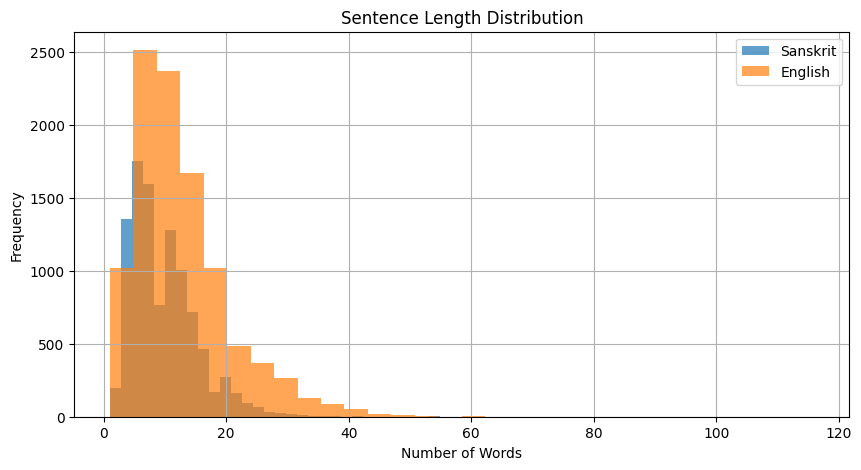

In [12]:
# ============================================================
# Plot Sentence Length Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    train_df["sa_length"],
    bins=30,
    alpha=0.7,
    label="Sanskrit"
)

plt.hist(
    train_df["en_length"],
    bins=30,
    alpha=0.7,
    label="English"
)

plt.title("Sentence Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
# ============================================================
# Build Vocabulary Class
# ============================================================

class Vocabulary:

    def __init__(self):

        self.word2idx = {
            "<PAD>":0,
            "<SOS>":1,
            "<EOS>":2,
            "<UNK>":3
        }

        self.idx2word = {
            0:"<PAD>",
            1:"<SOS>",
            2:"<EOS>",
            3:"<UNK>"
        }

        self.word_count = Counter()

    def build_vocab(self, sentences):

        for sentence in sentences:

            words = sentence.split()

            self.word_count.update(words)

        index = 4

        for word in self.word_count:

            self.word2idx[word] = index
            self.idx2word[index] = word
            index += 1

    def numericalize(self, sentence):

        return [
            self.word2idx.get(word, self.word2idx["<UNK>"])
            for word in sentence.split()
        ]

In [14]:
# ============================================================
# Create Sanskrit and English Vocabulary
# ============================================================

source_vocab = Vocabulary()
target_vocab = Vocabulary()

source_vocab.build_vocab(train_df["Sentence_sa"])

target_vocab.build_vocab(train_df["Sentence_en"])

print("Sanskrit Vocabulary Size :", len(source_vocab.word2idx))

print("English Vocabulary Size :", len(target_vocab.word2idx))

Sanskrit Vocabulary Size : 33278
English Vocabulary Size : 19552


In [15]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

class TranslationDataset(Dataset):
    """
    Dataset class for Sanskrit-English Translation.

    Each item returns:
    - Sanskrit sentence as token IDs
    - English sentence as token IDs
    """

    def __init__(self, dataframe, source_vocab, target_vocab):

        self.data = dataframe
        self.source_vocab = source_vocab
        self.target_vocab = target_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        source_sentence = self.data.iloc[index]["Sentence_sa"]
        target_sentence = self.data.iloc[index]["Sentence_en"]

        source_ids = self.source_vocab.numericalize(source_sentence)

        target_ids = [self.target_vocab.word2idx["<SOS>"]]

        target_ids += self.target_vocab.numericalize(target_sentence)

        target_ids.append(self.target_vocab.word2idx["<EOS>"])

        return source_ids, target_ids

In [16]:
# ============================================================
# Padding Function
# ============================================================

PAD_IDX = source_vocab.word2idx["<PAD>"]

def collate_fn(batch):

    source_sentences = [torch.tensor(x[0]) for x in batch]
    target_sentences = [torch.tensor(x[1]) for x in batch]

    source_sentences = nn.utils.rnn.pad_sequence(
        source_sentences,
        batch_first=True,
        padding_value=PAD_IDX
    )

    target_sentences = nn.utils.rnn.pad_sequence(
        target_sentences,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return source_sentences, target_sentences


# ============================================================
# Create Dataset Objects
# ============================================================

train_dataset = TranslationDataset(
    train_df,
    source_vocab,
    target_vocab
)

dev_dataset = TranslationDataset(
    dev_df,
    source_vocab,
    target_vocab
)

test_dataset = TranslationDataset(
    test_df,
    source_vocab,
    target_vocab
)


# ============================================================
# Create DataLoaders
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Training Batches :", len(train_loader))
print("Validation Batches :", len(dev_loader))
print("Testing Batches :", len(test_loader))

Training Batches : 313
Validation Batches : 32
Testing Batches : 32


In [17]:
# ============================================================
# Encoder Network
# ============================================================

class Encoder(nn.Module):

    def __init__(
        self,
        input_size,
        embedding_size,
        hidden_size,
        num_layers,
        dropout
    ):

        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(
            input_size,
            embedding_size,
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embedding_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

    def forward(self, source):

        embedded = self.dropout(
            self.embedding(source)
        )

        outputs, hidden = self.gru(embedded)

        return outputs, hidden

In [18]:
# ============================================================
# Bahdanau Attention Mechanism
# ============================================================

class Attention(nn.Module):

    def __init__(self, hidden_size):

        super().__init__()

        self.energy = nn.Linear(
            hidden_size * 2,
            hidden_size
        )

        self.v = nn.Linear(
            hidden_size,
            1,
            bias=False
        )

    def forward(
        self,
        hidden,
        encoder_outputs
    ):

        batch_size = encoder_outputs.shape[0]

        seq_len = encoder_outputs.shape[1]

        hidden = hidden[-1].unsqueeze(1)

        hidden = hidden.repeat(1, seq_len, 1)

        energy = torch.tanh(
            self.energy(
                torch.cat(
                    (hidden, encoder_outputs),
                    dim=2
                )
            )
        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [19]:
# ============================================================
# Decoder Network
# ============================================================

class Decoder(nn.Module):

    def __init__(
        self,
        output_size,
        embedding_size,
        hidden_size,
        num_layers,
        dropout,
        attention
    ):

        super().__init__()

        self.output_size = output_size
        self.hidden_size = hidden_size

        self.attention = attention

        self.embedding = nn.Embedding(
            output_size,
            embedding_size,
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embedding_size + hidden_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size * 2,
            output_size
        )

    def forward(
        self,
        input_word,
        hidden,
        encoder_outputs
    ):

        input_word = input_word.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input_word)
        )

        attention_weights = self.attention(
            hidden,
            encoder_outputs
        )

        attention_weights = attention_weights.unsqueeze(1)

        context = torch.bmm(
            attention_weights,
            encoder_outputs
        )

        gru_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        prediction = self.fc(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden

In [20]:
# ============================================================
# Complete Seq2Seq Model
# ============================================================

class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        source,
        target,
        teacher_forcing_ratio=0.5
    ):

        batch_size = source.shape[0]

        target_length = target.shape[1]

        target_vocab_size = self.decoder.output_size

        outputs = torch.zeros(
            batch_size,
            target_length,
            target_vocab_size
        ).to(self.device)

        encoder_outputs, hidden = self.encoder(source)

        input_word = target[:, 0]

        for t in range(1, target_length):

            output, hidden = self.decoder(
                input_word,
                hidden,
                encoder_outputs
            )

            outputs[:, t] = output

            best_guess = output.argmax(1)

            teacher_force = random.random() < teacher_forcing_ratio

            input_word = (
                target[:, t]
                if teacher_force
                else best_guess
            )

        return outputs

In [21]:
# ============================================================
# Cell 19: Model Initialization
# ============================================================
# Initialize Encoder, Attention, Decoder and Seq2Seq Model
# ============================================================

# Model Hyperparameters
INPUT_DIM = len(source_vocab.word2idx)
OUTPUT_DIM = len(target_vocab.word2idx)

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.2

# Create Encoder
encoder = Encoder(
    input_size=INPUT_DIM,
    embedding_size=EMBEDDING_DIM,
    hidden_size=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Create Attention
attention = Attention(
    hidden_size=HIDDEN_DIM
)

# Create Decoder
decoder = Decoder(
    output_size=OUTPUT_DIM,
    embedding_size=EMBEDDING_DIM,
    hidden_size=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    attention=attention
)

# Build Seq2Seq Model
model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=device
)

# Move model to GPU (if available)
model = model.to(device)

print("=" * 60)
print("Seq2Seq Model Initialized Successfully")
print("=" * 60)

print(f"Source Vocabulary Size : {INPUT_DIM:,}")
print(f"Target Vocabulary Size : {OUTPUT_DIM:,}")
print(f"Embedding Dimension    : {EMBEDDING_DIM}")
print(f"Hidden Dimension       : {HIDDEN_DIM}")
print(f"GRU Layers             : {NUM_LAYERS}")
print(f"Dropout               : {DROPOUT}")

# ------------------------------------------------------------
# Count Total Trainable Parameters
# ------------------------------------------------------------
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"\nTotal Trainable Parameters : {total_parameters:,}")

Seq2Seq Model Initialized Successfully
Source Vocabulary Size : 33,278
Target Vocabulary Size : 19,552
Embedding Dimension    : 128
Hidden Dimension       : 256
GRU Layers             : 1
Dropout               : 0.2

Total Trainable Parameters : 17,713,504


In [22]:
# ============================================================
# Cell 20: Define Loss Function and Optimizer
# ============================================================

# Loss Function
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 60)
print("Loss Function and Optimizer Initialized")
print("=" * 60)

print("Loss Function :", criterion)
print("Optimizer     :", optimizer)
print("Learning Rate :", optimizer.param_groups[0]["lr"])

Loss Function and Optimizer Initialized
Loss Function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning Rate : 0.001


In [23]:
# ============================================================
# Cell 21: Training Function
# ============================================================
# This function trains the Seq2Seq model for one epoch.
# It performs:
# 1. Forward pass
# 2. Loss calculation
# 3. Backpropagation
# 4. Gradient clipping
# 5. Parameter update
# ============================================================

def train(model, dataloader, optimizer, criterion, clip=1.0):

    model.train()

    epoch_loss = 0

    for batch_idx, (source, target) in enumerate(tqdm(dataloader)):

        source = source.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(
            source,
            target
        )

        # output shape:
        # (batch_size, target_length, vocab_size)

        output_dim = output.shape[-1]

        # Ignore the <SOS> token
        output = output[:, 1:].reshape(-1, output_dim)
        target = target[:, 1:].reshape(-1)

        # Compute loss
        loss = criterion(output, target)

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [24]:
# ============================================================
# Cell 22: Validation Function
# ============================================================
# This function evaluates the model on the validation set.
# No gradients are computed during validation.
# ============================================================

def evaluate(model, dataloader, criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for source, target in tqdm(dataloader):

            source = source.to(device)
            target = target.to(device)

            # Disable teacher forcing during evaluation
            output = model(
                source,
                target,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[:, 1:].reshape(-1, output_dim)
            target = target[:, 1:].reshape(-1)

            loss = criterion(output, target)

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [25]:
# ============================================================
# Cell 23: Optimized Training Loop
# ============================================================

NUM_EPOCHS = 8          # Reduced from 15
best_valid_loss = float("inf")

train_losses = []
valid_losses = []

print("="*70)
print("Training Started...")
print("="*70)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    valid_loss = evaluate(
        model,
        dev_loader,
        criterion
    )

    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Valid Loss: {valid_loss:.4f}"
        f" | Time: {elapsed:.1f}s"
    )

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            "best_seq2seq_model.pth"
        )

        print("✓ Best model saved!")

    # Early stopping
    if train_loss < 0.10:
        print("Early stopping...")
        break

print("\nTraining Finished.")

Training Started...


100%|██████████| 32/32 [00:03<00:00,  9.26it/s]


Epoch 1/8 | Train Loss: 7.1319 | Valid Loss: 6.8849 | Time: 68.4s
✓ Best model saved!


100%|██████████| 32/32 [00:02<00:00, 10.83it/s]


Epoch 2/8 | Train Loss: 6.2712 | Valid Loss: 6.8594 | Time: 67.5s
✓ Best model saved!


...

Epoch 6/8 | Train Loss: 4.0430 | Valid Loss: 7.2000 | Time: 67.9s


100%|██████████| 32/32 [00:03<00:00, 10.14it/s]


Epoch 7/8 | Train Loss: 3.5425 | Valid Loss: 7.2637 | Time: 68.0s


100%|██████████| 32/32 [00:02<00:00, 10.69it/s]

Epoch 8/8 | Train Loss: 3.3403 | Valid Loss: 7.3461 | Time: 68.2s

Training Finished.


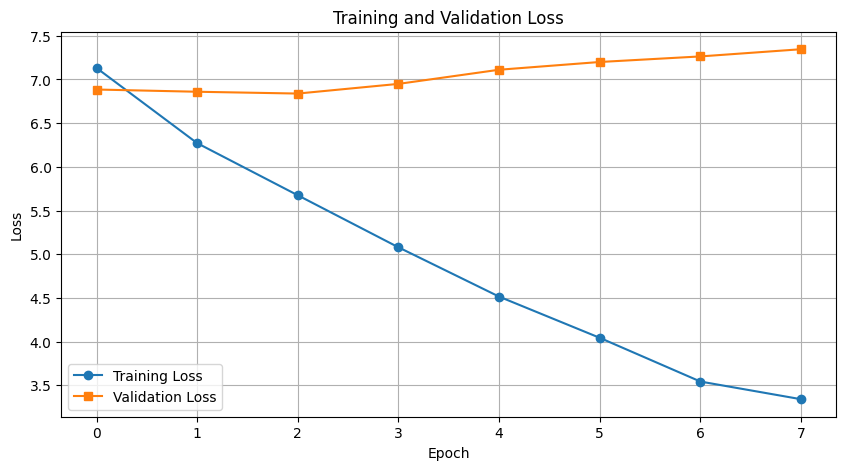

In [26]:
# ============================================================
# Cell 24: Plot Training & Validation Loss
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Training Loss",
    marker="o"
)

plt.plot(
    valid_losses,
    label="Validation Loss",
    marker="s"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.grid(True)

plt.legend()

plt.show()

In [27]:
# ============================================================
# Cell 25: Load Best Saved Model
# ============================================================
# Load the model with the lowest validation loss.
# This model will be used for inference on the test set.
# ============================================================

import os

MODEL_PATH = "best_seq2seq_model.pth"

if os.path.exists(MODEL_PATH):

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device
        )
    )

    model.eval()

    print("=" * 60)
    print("✓ Best model loaded successfully.")
    print("=" * 60)

else:

    print("=" * 60)
    print("Model file not found!")
    print("Please train the model first.")
    print("=" * 60)

✓ Best model loaded successfully.


In [28]:
# ============================================================
# Cell 26: Translation Function
# ============================================================
# This function translates a Sanskrit sentence into English
# using the trained Seq2Seq model.
# ============================================================

def translate_sentence(sentence, max_length=50):

    model.eval()

    # Clean input sentence
    sentence = clean_text(sentence)

    # Convert sentence to token IDs
    source_ids = source_vocab.numericalize(sentence)

    source_tensor = torch.LongTensor(source_ids).unsqueeze(0).to(device)

    with torch.no_grad():

        encoder_outputs, hidden = model.encoder(source_tensor)

    # Start with <SOS>
    input_token = torch.tensor(
        [target_vocab.word2idx["<SOS>"]],
        dtype=torch.long,
        device=device
    )

    translated_sentence = []

    for _ in range(max_length):

        with torch.no_grad():

            prediction, hidden = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

        best_token = prediction.argmax(1).item()

        # Stop when <EOS> is generated
        if best_token == target_vocab.word2idx["<EOS>"]:
            break

        translated_sentence.append(
            target_vocab.idx2word.get(best_token, "<UNK>")
        )

        input_token = torch.tensor(
            [best_token],
            dtype=torch.long,
            device=device
        )

    return " ".join(translated_sentence)

In [29]:
# ============================================================
# Cell 27: Translate One Sample Sentence
# ============================================================

sample_index = 0

source_sentence = test_df.iloc[sample_index]["Sentence_sa"]

reference_translation = test_df.iloc[sample_index]["Sentence_en"]

predicted_translation = translate_sentence(source_sentence)

print("=" * 70)
print("Sanskrit Sentence")
print("=" * 70)
print(source_sentence)

print("\nReference Translation")
print("-" * 70)
print(reference_translation)

print("\nPredicted Translation")
print("-" * 70)
print(predicted_translation)

Sanskrit Sentence
एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

Reference Translation
----------------------------------------------------------------------
Eclipse also helps the programmer to find out errors.

Predicted Translation
----------------------------------------------------------------------
So, the the the the the the the the


In [30]:
# ============================================================
# Cell 28: Generate Predictions for Entire Test Set
# ============================================================

predictions = []

start_time = time.time()

for sentence in tqdm(test_df["Sentence_sa"]):

    prediction = translate_sentence(sentence)

    predictions.append(prediction)

end_time = time.time()

total_inference_time = end_time - start_time

print("=" * 70)
print("Prediction Completed")
print("=" * 70)

print(f"Total Inference Time : {total_inference_time:.2f} seconds")
print(f"Total Test Samples   : {len(predictions)}")

100%|██████████| 1000/1000 [00:12<00:00, 78.73it/s]

Prediction Completed
Total Inference Time : 12.71 seconds
Total Test Samples   : 1000


In [31]:
# ============================================================
# Cell 29: Calculate BLEU Score
# ============================================================

from nltk.translate.bleu_score import corpus_bleu

references = [
    [sentence.split()]
    for sentence in test_df["Sentence_en"]
]

hypotheses = [
    sentence.split()
    for sentence in predictions
]

bleu_score = corpus_bleu(
    references,
    hypotheses
)

print("=" * 60)
print(f"BLEU Score : {bleu_score:.4f}")
print("=" * 60)

BLEU Score : 0.0206


In [32]:
# ============================================================
# Cell 30: Calculate BERTScore
# ============================================================

from bert_score import score

P, R, F1 = score(
    predictions,
    test_df["Sentence_en"].tolist(),
    lang="en",
    rescale_with_baseline=True
)

print("=" * 60)
print("Average BERTScore (F1)")
print("=" * 60)

print(f"Precision : {P.mean().item():.4f}")
print(f"Recall    : {R.mean().item():.4f}")
print(f"F1 Score  : {F1.mean().item():.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Average BERTScore (F1)
Precision : -0.1704
Recall    : 0.0334
F1 Score  : -0.0716


In [33]:
# ============================================================
# Cell 31: Model Statistics
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Model Statistics")
print("=" * 60)

print(f"Total Parameters      : {total_parameters:,}")
print(f"Trainable Parameters  : {trainable_parameters:,}")
print(f"Inference Time        : {total_inference_time:.2f} seconds")

Model Statistics
Total Parameters      : 17,713,504
Trainable Parameters  : 17,713,504
Inference Time        : 12.71 seconds


In [34]:
# ============================================================
# Cell 32: Create submission.csv
# ============================================================

submission = pd.DataFrame({
    "Source_id": test_df["Source_id"],
    "Sentence_en": predictions
})

submission.to_csv(
    "submission.csv",
    index=False,
    encoding="utf-8"
)

print("=" * 60)
print("submission.csv created successfully.")
print("=" * 60)

display(submission.head())

submission.csv created successfully.


,Source_id,Sentence_en
0,1,"So, the the the the the the the the"
1,2,"""And I had I had the the the the the the the"
2,3,I will learn about the the
3,4,The the is the the the the the the
4,5,"""And he had unto them, and the and of the and ..."


In [35]:
# ============================================================
# Cell 33: Display Sample Predictions
# ============================================================

num_examples = 10

examples = pd.DataFrame({
    "Sanskrit": test_df["Sentence_sa"][:num_examples],
    "Reference": test_df["Sentence_en"][:num_examples],
    "Prediction": predictions[:num_examples]
})

display(examples)

,Sanskrit,Reference,Prediction
0,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...,Eclipse also helps the programmer to find out ...,"So, the the the the the the the the"
1,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...,"""We having the same spirit of faith, according...","""And I had I had the the the the the the the"
2,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...",Then it will automatically begin searching for...,I will learn about the the
3,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...",The iterator will be set to each of the indice...,The the is the the the the the the
4,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...,"""And when he had opened the second seal, I hea...","""And he had unto them, and the and of the and ..."
5,"वयम्, ओब्जेक्ट्स् स्वकीयान् स्थितीन् फील्ड्स् ...",We know that objects store their individual st...,In the the the the the the the the the the the...
6,बाल: युष्मासु विश्वासं करोति ।,Boy has belief on you all.,Child has love in you all. in you all. in you ...
7,प्रकृति का अवलोकन करने से आप आश्चर्य चकित हो स...,Observing the nature helps create a sense of w...,This is a of the is called the
8,यूयं कीदृक् तस्याज्ञा अपालयत भयकम्पाभ्यां तं ग...,"""And his inward affection is more abundant tow...","""And ye answered of the and of the and of the ..."
9,"""वर्षाया: जलस्य कश्चन अंश: भूमौ शुष्को भूत्वा ...",A part of rain water is absorbedby earth. Wate...,"""And when they had the and the the the the and..."


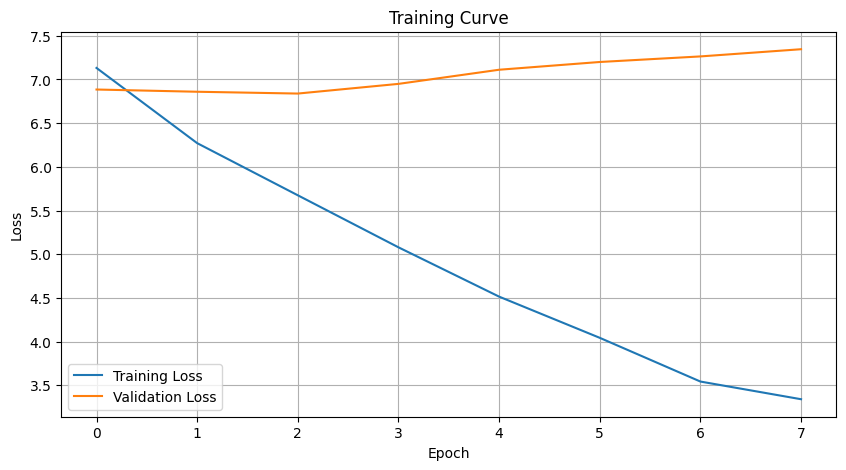

In [36]:
# ============================================================
# Cell 34: Save Training Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()